# Fake News & Bias Detection
## Advanced NLP & Machine Learning Pipeline

**Dataset:** LIAR (Wang 2017) — 12,791 short political statements, 6 veracity classes  
**Task:** Binary classification — *fake* vs *real*

**Pipeline:**
1. Setup & Imports
2. Data Loading
3. Exploratory Data Analysis
4. Feature Engineering (TF-IDF word + char n-grams + metadata)
5. Feature Selection (Chi-squared & Mutual Information)
6. Class Imbalance — SMOTE oversampling
7. Model Training — Baseline → Advanced → Ensemble
8. Hyperparameter Tuning (RandomizedSearchCV)
9. Comprehensive Evaluation (ROC, PR, Calibration, MCC)
10. Error Analysis
11. Feature Importance
12. Conclusion

In [42]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install -q scikit-learn nltk pandas numpy matplotlib seaborn xgboost imbalanced-learn wordcloud scipy



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from scipy.sparse import hstack, csr_matrix, issparse
from scipy.stats import mannwhitneyu, loguniform

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── GPU setup ────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,2), "GB")
else:
    print("No GPU found — running on CPU")
print("Device:", DEVICE)
print("All imports OK")


GPU : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.44 GB
Device: cuda
All imports OK


## 1. Data Loading

In [44]:
import urllib.request, zipfile

LIAR_URL = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
LIAR_ZIP = "liar_dataset.zip"
COLS = ["id","label","statement","subject","speaker","job_title",
        "state","party_affiliation","barely_true","false_count",
        "half_true","mostly_true","pants_fire","context"]

print("Downloading LIAR dataset...")
urllib.request.urlretrieve(LIAR_URL, LIAR_ZIP)

def load_tsv(zf, name):
    with zf.open(name) as f:
        return pd.read_csv(f, sep="\t", header=None, names=COLS)

with zipfile.ZipFile(LIAR_ZIP) as zf:
    train_df = load_tsv(zf, "train.tsv")
    val_df   = load_tsv(zf, "valid.tsv")
    test_df  = load_tsv(zf, "test.tsv")

df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df["label_name"] = df["label"]

REAL_LABELS = {"true", "mostly-true", "half-true"}
df["binary_label"]  = df["label_name"].apply(lambda x: "real" if x in REAL_LABELS else "fake")
df["binary_target"] = (df["binary_label"] == "fake").astype(int)

CREDIT_COLS = ["barely_true","false_count","half_true","mostly_true","pants_fire"]
for c in CREDIT_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())

df["text_length"] = df["statement"].str.split().str.len()

print("Total samples :", len(df))
print("Split sizes   : train={} / val={} / test={}".format(
    len(train_df), len(val_df), len(test_df)))
print()
print("Label distribution:")
print(df["label_name"].value_counts().to_string())
print()
print("Binary distribution:")
print(df["binary_label"].value_counts().to_string())
df[["statement","label_name","binary_label","speaker","party_affiliation"]].head(5)


Total samples : 12791
Split sizes   : train=10240 / val=1284 / test=1267

Label distribution:
label_name
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047

Binary distribution:
binary_label
real    7134
fake    5657


,statement,label_name,binary_label,speaker,party_affiliation
0,Says the Annies List political group supports ...,false,fake,dwayne-bohac,republican
1,When did the decline of coal start? It started...,half-true,real,scott-surovell,democrat
2,"Hillary Clinton agrees with John McCain ""by vo...",mostly-true,real,barack-obama,democrat
3,Health care reform legislation is likely to ma...,false,fake,blog-posting,none
4,The economic turnaround started at the end of ...,half-true,real,charlie-crist,democrat


## 2. Exploratory Data Analysis

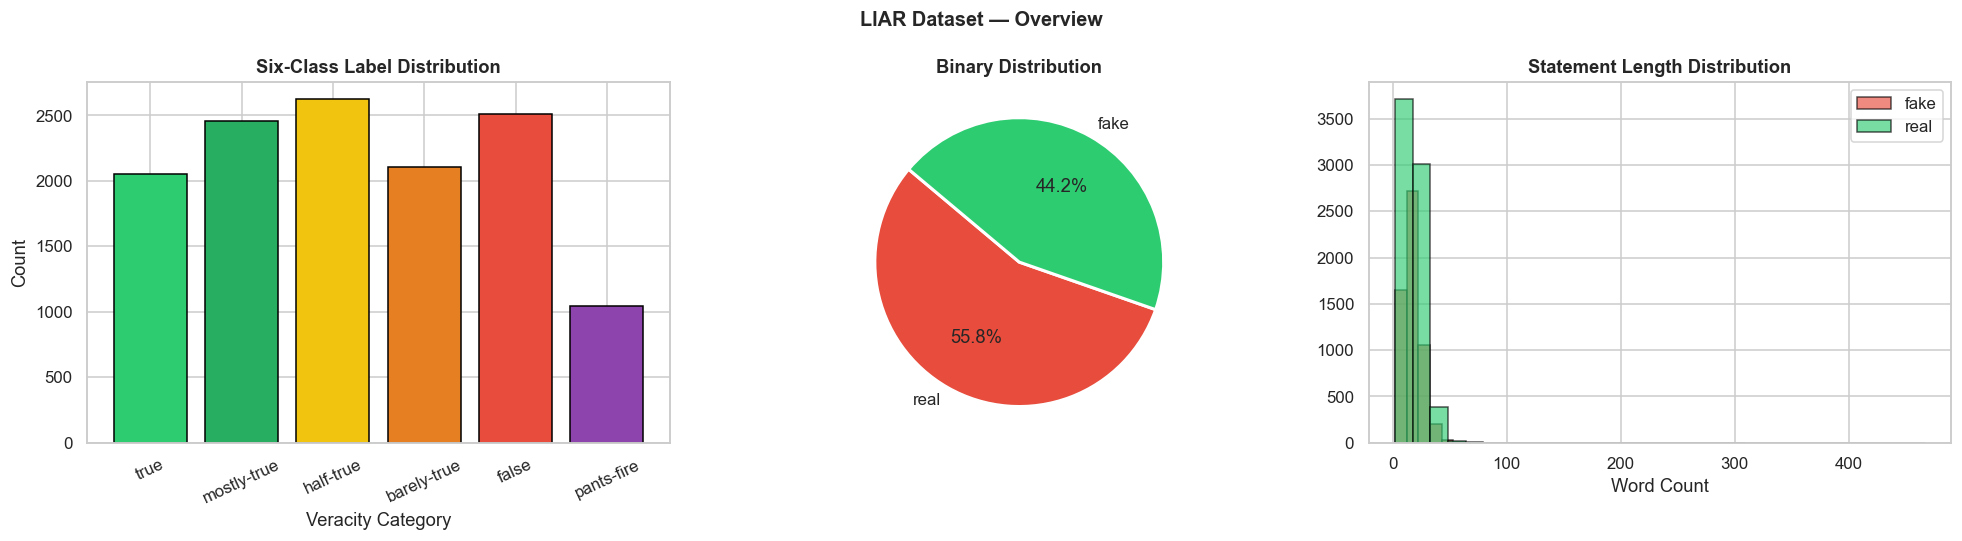

Avg words — Fake: 17.4  |  Real: 18.5


In [45]:
# ── 2a. Label distributions & statement length ───────────────────────────────
label_order = ["true","mostly-true","half-true","barely-true","false","pants-fire"]
counts_6 = df["label_name"].value_counts().reindex(label_order)
COLORS_6 = ["#2ecc71","#27ae60","#f1c40f","#e67e22","#e74c3c","#8e44ad"]

fig, axes = plt.subplots(1,3,figsize=(18,5))
axes[0].bar(counts_6.index, counts_6.values, color=COLORS_6, edgecolor="black")
axes[0].set_title("Six-Class Label Distribution", fontweight="bold")
axes[0].set_xlabel("Veracity Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=25)

axes[1].pie(df["binary_label"].value_counts().values,
            labels=df["binary_label"].value_counts().index,
            colors=["#e74c3c","#2ecc71"], autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white",linewidth=2))
axes[1].set_title("Binary Distribution", fontweight="bold")

for lbl, col in zip(["fake","real"],["#e74c3c","#2ecc71"]):
    axes[2].hist(df.loc[df["binary_label"]==lbl,"text_length"],
                 bins=30, alpha=0.65, label=lbl, color=col, edgecolor="black")
axes[2].set_title("Statement Length Distribution", fontweight="bold")
axes[2].set_xlabel("Word Count")
axes[2].legend()

plt.suptitle("LIAR Dataset — Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fn_eda_overview.png", bbox_inches="tight")
plt.show()

print("Avg words — Fake: {:.1f}  |  Real: {:.1f}".format(
    df.loc[df["binary_label"]=="fake","text_length"].mean(),
    df.loc[df["binary_label"]=="real","text_length"].mean()))


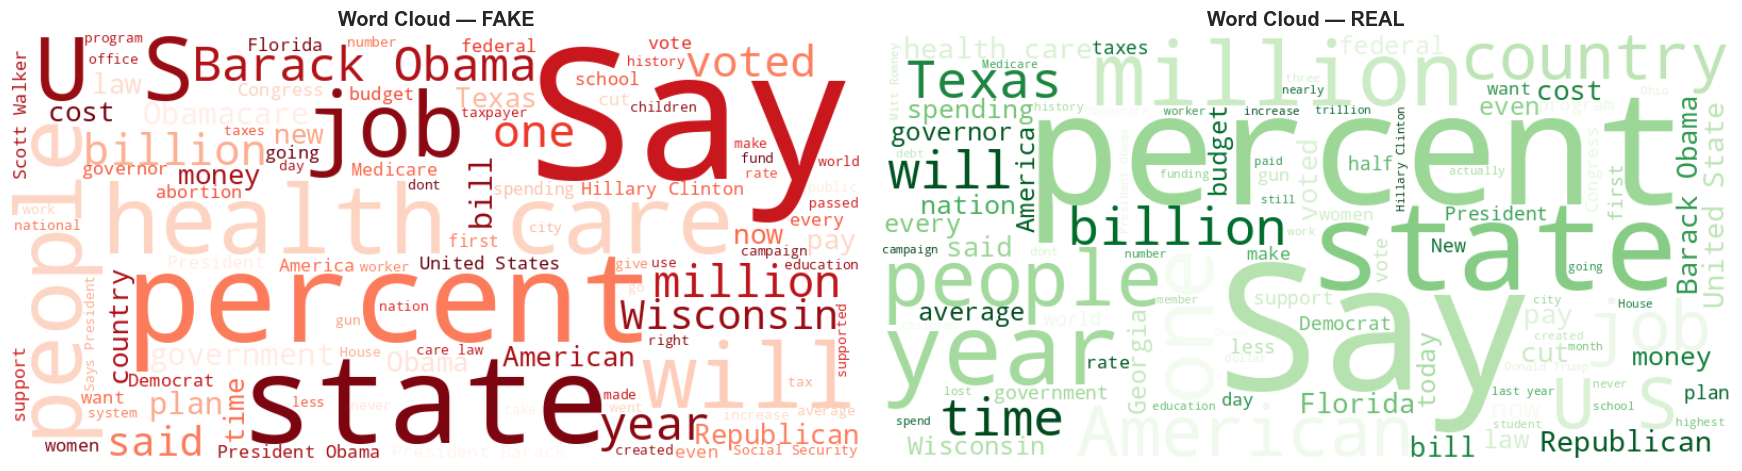

In [46]:
# ── 2b. Word clouds: Fake vs Real ────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(16,5))
for ax, label, cmap in zip(axes, ["fake","real"], ["Reds","Greens"]):
    text = " ".join(df.loc[df["binary_label"]==label,"statement"].dropna())
    wc = WordCloud(width=800, height=400, background_color="white",
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud — {}".format(label.upper()), fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fn_wordclouds.png", bbox_inches="tight")
plt.show()


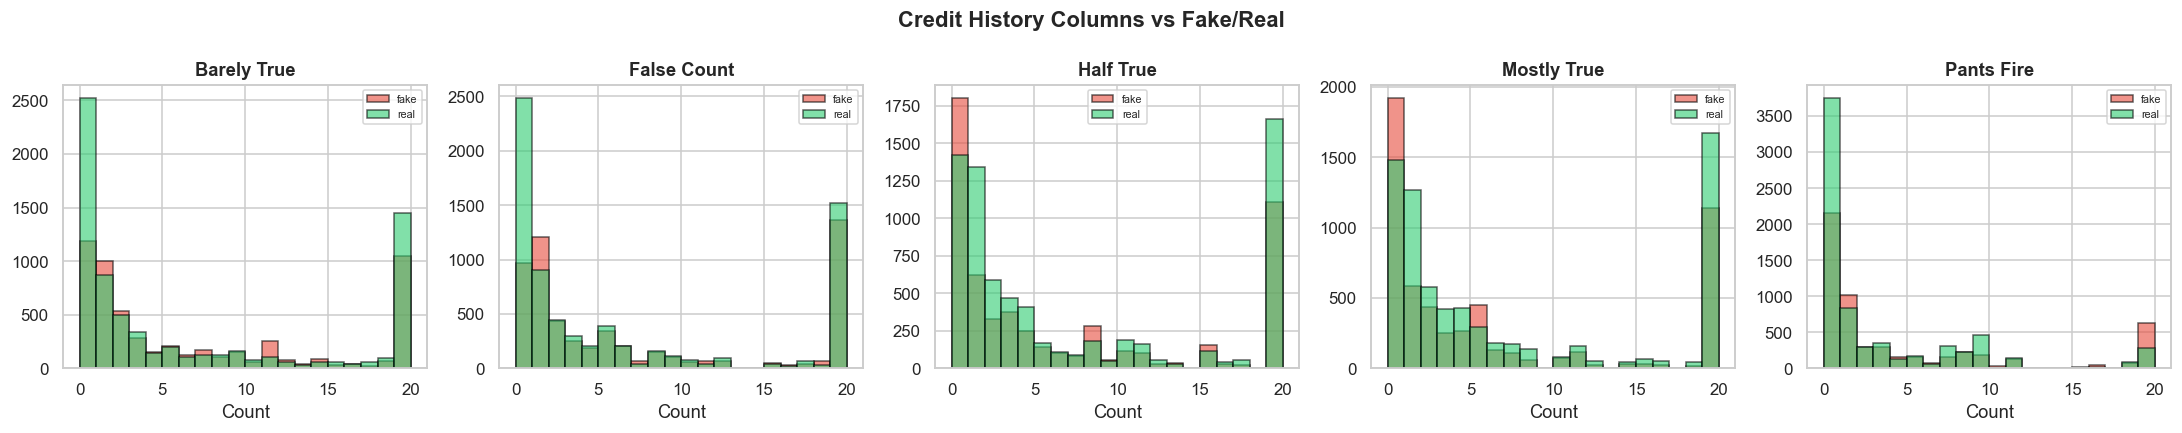

Feature                    U-stat        p-value
------------------------------------------------
barely_true              22134264     1.1082e-21
false_count              23041018     2.1708e-44
half_true                18468156     7.8951e-17
mostly_true              17905734     1.4656e-28
pants_fire               23227847     2.9595e-54


In [47]:
# ── 2c. Credit history distributions & statistical significance ───────────────
fig, axes = plt.subplots(1,5,figsize=(20,4))
for ax, col in zip(axes, CREDIT_COLS):
    for lbl, col_c in zip(["fake","real"],["#e74c3c","#2ecc71"]):
        ax.hist(df.loc[df["binary_label"]==lbl,col].clip(upper=20),
                bins=20, alpha=0.6, label=lbl, color=col_c, edgecolor="black")
    ax.set_title(col.replace("_"," ").title(), fontweight="bold")
    ax.set_xlabel("Count")
    ax.legend(fontsize=7)
plt.suptitle("Credit History Columns vs Fake/Real", fontweight="bold")
plt.tight_layout()
plt.savefig("fn_credit_history.png", bbox_inches="tight")
plt.show()

print("{:<22} {:>10} {:>14}".format("Feature","U-stat","p-value"))
print("-"*48)
for col in CREDIT_COLS:
    stat, p = mannwhitneyu(
        df.loc[df["binary_label"]=="fake", col],
        df.loc[df["binary_label"]=="real", col],
        alternative="two-sided"
    )
    print("{:<22} {:>10.0f} {:>14.4e}".format(col, stat, p))


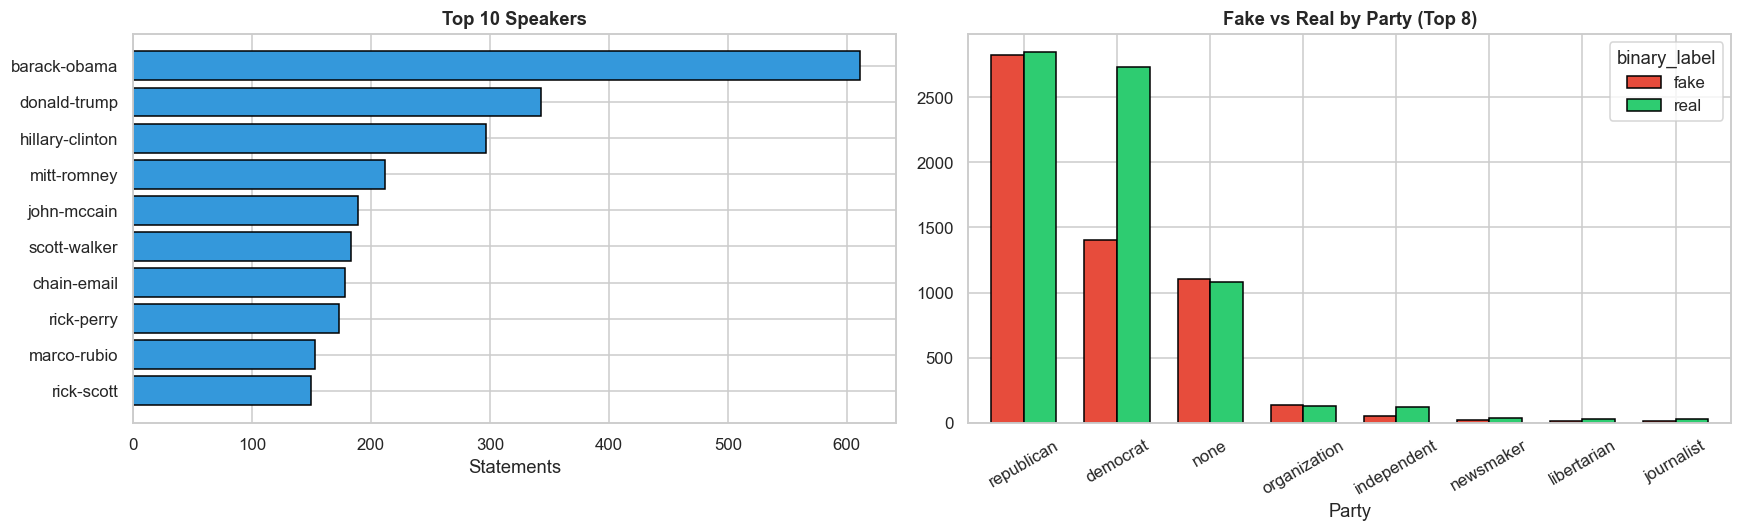

In [48]:
# ── 2d. Top speakers & party breakdown ───────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(16,5))

top_speakers = df["speaker"].value_counts().head(10)
axes[0].barh(top_speakers.index[::-1], top_speakers.values[::-1],
             color="#3498db", edgecolor="black")
axes[0].set_title("Top 10 Speakers", fontweight="bold")
axes[0].set_xlabel("Statements")

party_binary = df.groupby(["party_affiliation","binary_label"]).size().unstack(fill_value=0)
top_parties  = party_binary.sum(axis=1).nlargest(8).index
party_binary.loc[top_parties].plot(
    kind="bar", ax=axes[1],
    color=["#e74c3c","#2ecc71"], edgecolor="black", width=0.7)
axes[1].set_title("Fake vs Real by Party (Top 8)", fontweight="bold")
axes[1].set_xlabel("Party")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fn_speakers_party.png", bbox_inches="tight")
plt.show()


## 3. Feature Engineering

Three feature groups are built and concatenated into a single sparse matrix:

| Group | Description |
|-------|-------------|
| **TF-IDF word n-grams** | Unigrams + bigrams, 20 k features, sublinear TF, Porter stemming |
| **TF-IDF char n-grams** | Character 3–5-grams, 15 k features — captures style, morphology, punctuation habits |
| **Metadata** | Credit-history ratios, lie score, statement length, party one-hot encoding |

In [49]:
# ── 3a. Text preprocessing with stemming ─────────────────────────────────────
STOP_WORDS = set(stopwords.words("english"))
stemmer    = PorterStemmer()

def preprocess(text, stem=True):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    if stem:
        tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

df["processed"]     = df["statement"].apply(preprocess)
df["processed_raw"] = df["statement"].apply(lambda t: preprocess(t, stem=False))

print("Sample preprocessing:")
for i in range(2):
    print("  Original :", df["statement"].iloc[i])
    print("  Stemmed  :", df["processed"].iloc[i])
    print()


Sample preprocessing:
  Original : Says the Annies List political group supports third-trimester abortions on demand.
  Stemmed  : say anni list polit group support third trimest abort demand

  Original : When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.
  Stemmed  : declin coal start start natur ga took start begin presid georg bush administr



In [50]:
# ── 3b. Word n-gram TF-IDF ───────────────────────────────────────────────────
tfidf_word = TfidfVectorizer(
    max_features=20_000, ngram_range=(1,2),
    min_df=2, max_df=0.95, sublinear_tf=True, analyzer="word",
)
X_word = tfidf_word.fit_transform(df["processed"])
print("Word TF-IDF :", X_word.shape)

# ── 3c. Character n-gram TF-IDF ──────────────────────────────────────────────
tfidf_char = TfidfVectorizer(
    max_features=15_000, ngram_range=(3,5),
    min_df=3, max_df=0.95, sublinear_tf=True, analyzer="char_wb",
)
X_char = tfidf_char.fit_transform(df["processed_raw"])
print("Char TF-IDF :", X_char.shape)


Word TF-IDF : (12791, 18005)
Char TF-IDF : (12791, 15000)


In [51]:
# ── 3d. Metadata features ────────────────────────────────────────────────────
meta = df[CREDIT_COLS].copy()

meta["total"] = meta[CREDIT_COLS].sum(axis=1).clip(lower=1)
for c in CREDIT_COLS:
    meta[c + "_ratio"] = meta[c] / meta["total"]

# Weighted lie score
meta["lie_score"] = (
    meta["pants_fire"] * 3 + meta["false_count"] * 2 + meta["barely_true"] * 1
    - meta["mostly_true"] * 1 - meta["half_true"] * 0.5
) / meta["total"]

meta["text_length"]     = df["text_length"]
meta["char_length"]     = df["statement"].str.len()
meta["avg_word_length"] = meta["char_length"] / meta["text_length"].clip(lower=1)

# Party one-hot (top 8)
top_party_list = df["party_affiliation"].value_counts().head(8).index.tolist()
for p in top_party_list:
    meta["party_" + p] = (df["party_affiliation"] == p).astype(int)

meta = meta.drop(columns=["total"])

# MinMax-scale metadata to [0,1] so chi2 selector accepts it
from sklearn.preprocessing import MinMaxScaler
meta_scaled = MinMaxScaler().fit_transform(meta.values.astype(float))
X_meta = csr_matrix(meta_scaled)
print("Metadata    :", X_meta.shape)
print("Features    :", meta.columns.tolist())


Metadata    : (12791, 22)
Features    : ['barely_true', 'false_count', 'half_true', 'mostly_true', 'pants_fire', 'barely_true_ratio', 'false_count_ratio', 'half_true_ratio', 'mostly_true_ratio', 'pants_fire_ratio', 'lie_score', 'text_length', 'char_length', 'avg_word_length', 'party_republican', 'party_democrat', 'party_none', 'party_organization', 'party_independent', 'party_newsmaker', 'party_libertarian', 'party_journalist']


In [52]:
# ── 3e. Combine all features & split ─────────────────────────────────────────
X_combined = hstack([X_word, X_char, X_meta])
y = df["binary_target"].values
print("Combined matrix:", X_combined.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.20, random_state=SEED, stratify=y
)
print("Train: {}  |  Test: {}".format(X_train.shape[0], X_test.shape[0]))


Combined matrix: (12791, 33027)
Train: 10232  |  Test: 2559


## 4. Feature Selection

Chi-squared and Mutual Information rank features independently.  
The **union mask** keeps any feature flagged by either test, preserving complementary signals.

Chi2 selected   : 15000
MI selected     : 15000
Union selected  : 25006


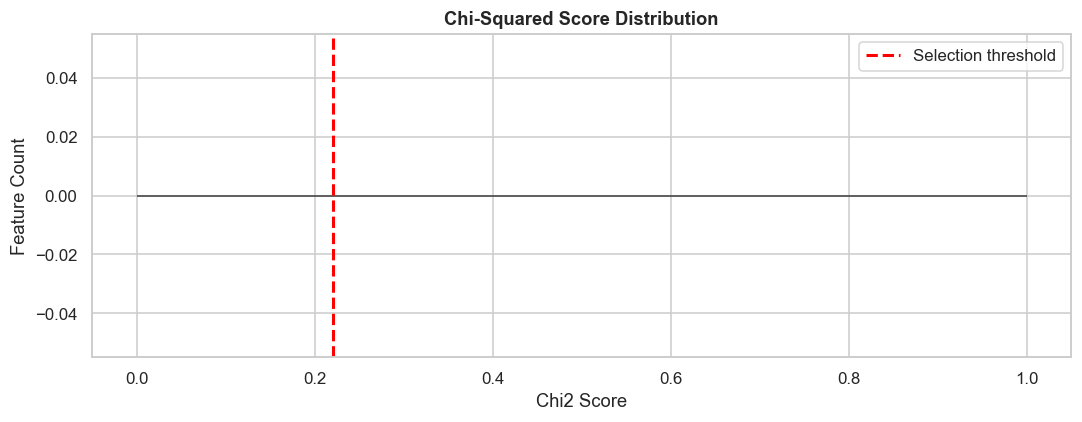

In [53]:
# ── 4. Chi2 + Mutual Information union selection ──────────────────────────────
K_BEST = 15_000

selector_chi2 = SelectKBest(chi2, k=K_BEST)
selector_chi2.fit(X_train, y_train)

selector_mi = SelectKBest(mutual_info_classif, k=K_BEST)
selector_mi.fit(X_train, y_train)

mask_chi2  = selector_chi2.get_support()
mask_mi    = selector_mi.get_support()
mask_union = mask_chi2 | mask_mi

X_train_fs = X_train[:, mask_union]
X_test_fs  = X_test[:, mask_union]

print("Chi2 selected   :", mask_chi2.sum())
print("MI selected     :", mask_mi.sum())
print("Union selected  :", mask_union.sum())

# Plot top chi2 score distribution
chi2_scores = selector_chi2.scores_
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(chi2_scores[chi2_scores < np.percentile(chi2_scores,99)], bins=80,
        color="#3498db", edgecolor="black", alpha=0.7)
ax.axvline(np.sort(chi2_scores)[-K_BEST], color="red", lw=2, linestyle="--",
           label="Selection threshold")
ax.set_title("Chi-Squared Score Distribution", fontweight="bold")
ax.set_xlabel("Chi2 Score")
ax.set_ylabel("Feature Count")
ax.legend()
plt.tight_layout()
plt.savefig("fn_chi2_scores.png", bbox_inches="tight")
plt.show()


## 5. Class Imbalance — SMOTE

The binary split is ~56 % real / 44 % fake. SMOTE synthesises minority-class samples
in feature space on the **training set only** (never the test set).

In [54]:
# ── 5. SMOTE oversampling ────────────────────────────────────────────────────
print("Before SMOTE — Fake: {}  Real: {}".format(y_train.sum(), (y_train==0).sum()))

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fs, y_train)

print("After  SMOTE — Fake: {}  Real: {}".format(y_train_sm.sum(), (y_train_sm==0).sum()))
print("Training matrix after SMOTE:", X_train_sm.shape)


Before SMOTE — Fake: 4525  Real: 5707
After  SMOTE — Fake: 5707  Real: 5707
Training matrix after SMOTE: (11414, 25006)


## 6. Model Training

### 6a. Baseline Models

In [55]:
# ── 6a. Logistic Regression baseline ────────────────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs",
                        class_weight="balanced", random_state=SEED)
lr.fit(X_train_fs, y_train)
lr_pred  = lr.predict(X_test_fs)
lr_proba = lr.predict_proba(X_test_fs)[:,1]
print("Logistic Regression  Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, lr_pred), f1_score(y_test, lr_pred),
    roc_auc_score(y_test, lr_proba)))

# ── 6b. Complement Naive Bayes (better than Multinomial for imbalanced data) ──
cnb = ComplementNB(alpha=0.1)
cnb.fit(X_train_fs, y_train)
cnb_pred  = cnb.predict(X_test_fs)
cnb_proba = cnb.predict_proba(X_test_fs)[:,1]
print("Complement NB        Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, cnb_pred), f1_score(y_test, cnb_pred),
    roc_auc_score(y_test, cnb_proba)))

# ── 6c. Linear SVM ───────────────────────────────────────────────────────────
svm_base = CalibratedClassifierCV(
    LinearSVC(C=0.5, max_iter=3000, class_weight="balanced", random_state=SEED), cv=3)
svm_base.fit(X_train_fs, y_train)
svm_pred  = svm_base.predict(X_test_fs)
svm_proba = svm_base.predict_proba(X_test_fs)[:,1]
print("Linear SVM           Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, svm_pred), f1_score(y_test, svm_pred),
    roc_auc_score(y_test, svm_proba)))


Logistic Regression  Acc:0.7507  F1:0.7197  AUC:0.8376
Complement NB        Acc:0.6659  F1:0.6345  AUC:0.7228
Linear SVM           Acc:0.7460  F1:0.6999  AUC:0.8283


### 6b. Advanced Models

In [56]:
# ── 6d. XGBoost (GPU) ────────────────────────────────────────────────────────
scale_pos = float((y_train==0).sum()) / float(y_train.sum())
xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    device="cuda",
    eval_metric="logloss", random_state=SEED,
)
xgb.fit(X_train_fs, y_train)
xgb_pred  = xgb.predict(X_test_fs)
xgb_proba = xgb.predict_proba(X_test_fs)[:,1]
print("XGBoost              Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, xgb_pred), f1_score(y_test, xgb_pred),
    roc_auc_score(y_test, xgb_proba)))

# ── 6e. Gradient Boosting ────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=SEED
)
gb.fit(X_train_fs, y_train)
gb_pred  = gb.predict(X_test_fs)
gb_proba = gb.predict_proba(X_test_fs)[:,1]
print("Gradient Boosting    Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, gb_pred), f1_score(y_test, gb_pred),
    roc_auc_score(y_test, gb_proba)))


XGBoost              Acc:0.6815  F1:0.6411  AUC:0.7412
Gradient Boosting    Acc:0.7495  F1:0.7012  AUC:0.8364


### 6c. PyTorch MLP (GPU)

In [57]:
# ── 6f. PyTorch MLP trained on GPU ──────────────────────────────────────────
import time

class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# Convert sparse -> dense float32 tensors
X_tr_dense  = torch.tensor(X_train_fs.toarray(), dtype=torch.float32)
X_te_dense  = torch.tensor(X_test_fs.toarray(),  dtype=torch.float32)
y_tr_tensor = torch.tensor(y_train, dtype=torch.float32)
y_te_tensor = torch.tensor(y_test,  dtype=torch.float32)

train_ds = TensorDataset(X_tr_dense, y_tr_tensor)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

in_dim  = X_tr_dense.shape[1]
mlp     = MLP(in_dim).to(DEVICE)
pos_w   = torch.tensor([(y_train==0).sum() / y_train.sum()], dtype=torch.float32).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt     = torch.optim.AdamW(mlp.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=3e-3, epochs=30, steps_per_epoch=len(train_dl))

print("Training MLP on", DEVICE)
t0 = time.time()
mlp.train()
for epoch in range(30):
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss_fn(mlp(xb), yb).backward()
        opt.step()
        scheduler.step()
    if (epoch+1) % 10 == 0:
        print("  Epoch {:2d}/30 done".format(epoch+1))
print("Training time: {:.1f}s".format(time.time()-t0))

mlp.eval()
with torch.no_grad():
    logits    = mlp(X_te_dense.to(DEVICE)).cpu()
    mlp_proba = torch.sigmoid(logits).numpy()
    mlp_pred  = (mlp_proba >= 0.5).astype(int)

print("MLP (GPU)            Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, mlp_pred),
    f1_score(y_test, mlp_pred),
    roc_auc_score(y_test, mlp_proba)))


Training MLP on cuda
  Epoch 10/30 done
  Epoch 20/30 done
  Epoch 30/30 done
Training time: 17.7s
MLP (GPU)            Acc:0.7132  F1:0.6758  AUC:0.7863


### 6d. Hyperparameter Tuning — RandomizedSearchCV

In [58]:
# ── 6f. RandomizedSearchCV on Logistic Regression ────────────────────────────
param_dist = {
    "C":       loguniform(0.01, 10),
    "solver":  ["lbfgs","saga"],
    "max_iter":[500, 1000, 2000],
    "penalty": ["l2"],
}

lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight="balanced", random_state=SEED),
    param_distributions=param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1", n_jobs=-1, random_state=SEED, verbose=1,
)
lr_search.fit(X_train_fs, y_train)

print("Best params:", lr_search.best_params_)
print("Best CV F1 :", round(lr_search.best_score_, 4))

lr_tuned       = lr_search.best_estimator_
lr_tuned_pred  = lr_tuned.predict(X_test_fs)
lr_tuned_proba = lr_tuned.predict_proba(X_test_fs)[:,1]
print("Tuned LR             Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, lr_tuned_pred), f1_score(y_test, lr_tuned_pred),
    roc_auc_score(y_test, lr_tuned_proba)))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'C': np.float64(6.708188643346285), 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best CV F1 : 0.7162
Tuned LR             Acc:0.7378  F1:0.7069  AUC:0.8202


### 6d. Stacking Ensemble

In [59]:
# ── 6g. Stacking classifier ──────────────────────────────────────────────────
base_learners = [
    ("lr",  LogisticRegression(C=lr_search.best_params_["C"],
                               class_weight="balanced", max_iter=1000, random_state=SEED)),
    ("cnb", ComplementNB(alpha=0.1)),
    ("svm", CalibratedClassifierCV(
                LinearSVC(C=0.5, max_iter=3000, class_weight="balanced", random_state=SEED),
                cv=3)),
]
stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=1.0, class_weight="balanced", random_state=SEED),
    cv=5, passthrough=False, n_jobs=-1,
)
stack.fit(X_train_fs, y_train)
stack_pred  = stack.predict(X_test_fs)
stack_proba = stack.predict_proba(X_test_fs)[:,1]
print("Stacking Ensemble    Acc:{:.4f}  F1:{:.4f}  AUC:{:.4f}".format(
    accuracy_score(y_test, stack_pred), f1_score(y_test, stack_pred),
    roc_auc_score(y_test, stack_proba)))


Stacking Ensemble    Acc:0.7382  F1:0.7105  AUC:0.8191


### 6e. Cross-Validation (5-fold Stratified)

In [60]:
# ── 6h. 5-fold stratified CV comparison ─────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = {
    "LR (tuned)": lr_tuned,
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=3000, class_weight="balanced", random_state=SEED), cv=3),
    "XGBoost":    xgb,
}
print("{:<20} {:>10} {:>10} {:>10}".format("Model","Mean F1","Std F1","Mean AUC"))
print("-"*54)
for name, clf in cv_models.items():
    f1s  = cross_val_score(clf, X_train_fs, y_train, cv=skf, scoring="f1",      n_jobs=-1)
    aucs = cross_val_score(clf, X_train_fs, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    print("{:<20} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        name, f1s.mean(), f1s.std(), aucs.mean()))


Model                   Mean F1     Std F1   Mean AUC
------------------------------------------------------
LR (tuned)               0.7162     0.0039     0.8336
Linear SVM               0.7041     0.0079     0.8349
XGBoost                  0.6164     0.0108     0.7213


## 7. Comprehensive Evaluation

In [61]:
# ── 7a. Full metrics table ───────────────────────────────────────────────────
ALL_MODELS = {
    "Logistic Regression": (lr_pred,        lr_proba),
    "Complement NB":       (cnb_pred,        cnb_proba),
    "Linear SVM":          (svm_pred,        svm_proba),
    "XGBoost (GPU)":       (xgb_pred,        xgb_proba),
    "Gradient Boosting":   (gb_pred,         gb_proba),
    "MLP (GPU)":           (mlp_pred,        mlp_proba),
    "LR (Tuned)":          (lr_tuned_pred,   lr_tuned_proba),
    "Stacking Ensemble":   (stack_pred,      stack_proba),
}

rows = []
for name, (pred, proba) in ALL_MODELS.items():
    rows.append({
        "Model":    name,
        "Accuracy": round(accuracy_score(y_test,  pred),  4),
        "Precision":round(precision_score(y_test, pred),  4),
        "Recall":   round(recall_score(y_test,    pred),  4),
        "F1":       round(f1_score(y_test,         pred),  4),
        "MCC":      round(matthews_corrcoef(y_test, pred), 4),
        "ROC-AUC":  round(roc_auc_score(y_test,   proba), 4),
        "Avg-Prec": round(average_precision_score(y_test, proba), 4),
    })

results = pd.DataFrame(rows).set_index("Model")
results_sorted = results.sort_values("F1", ascending=False)
print(results_sorted.to_string())


                     Accuracy  Precision  Recall      F1     MCC  ROC-AUC  Avg-Prec
Model                                                                              
Logistic Regression    0.7507     0.7159  0.7235  0.7197  0.4952   0.8376    0.8087
Stacking Ensemble      0.7382     0.6954  0.7261  0.7105  0.4721   0.8191    0.7857
LR (Tuned)             0.7378     0.6992  0.7147  0.7069  0.4698   0.8202    0.7804
Gradient Boosting      0.7495     0.7423  0.6643  0.7012  0.4889   0.8364    0.8063
Linear SVM             0.7460     0.7331  0.6696  0.6999  0.4820   0.8283    0.7938
MLP (GPU)              0.7132     0.6758  0.6758  0.6758  0.4186   0.7863    0.7358
XGBoost (GPU)          0.6815     0.6392  0.6431  0.6411  0.3549   0.7412    0.6638
Complement NB          0.6659     0.6147  0.6555  0.6345  0.3279   0.7228    0.6735


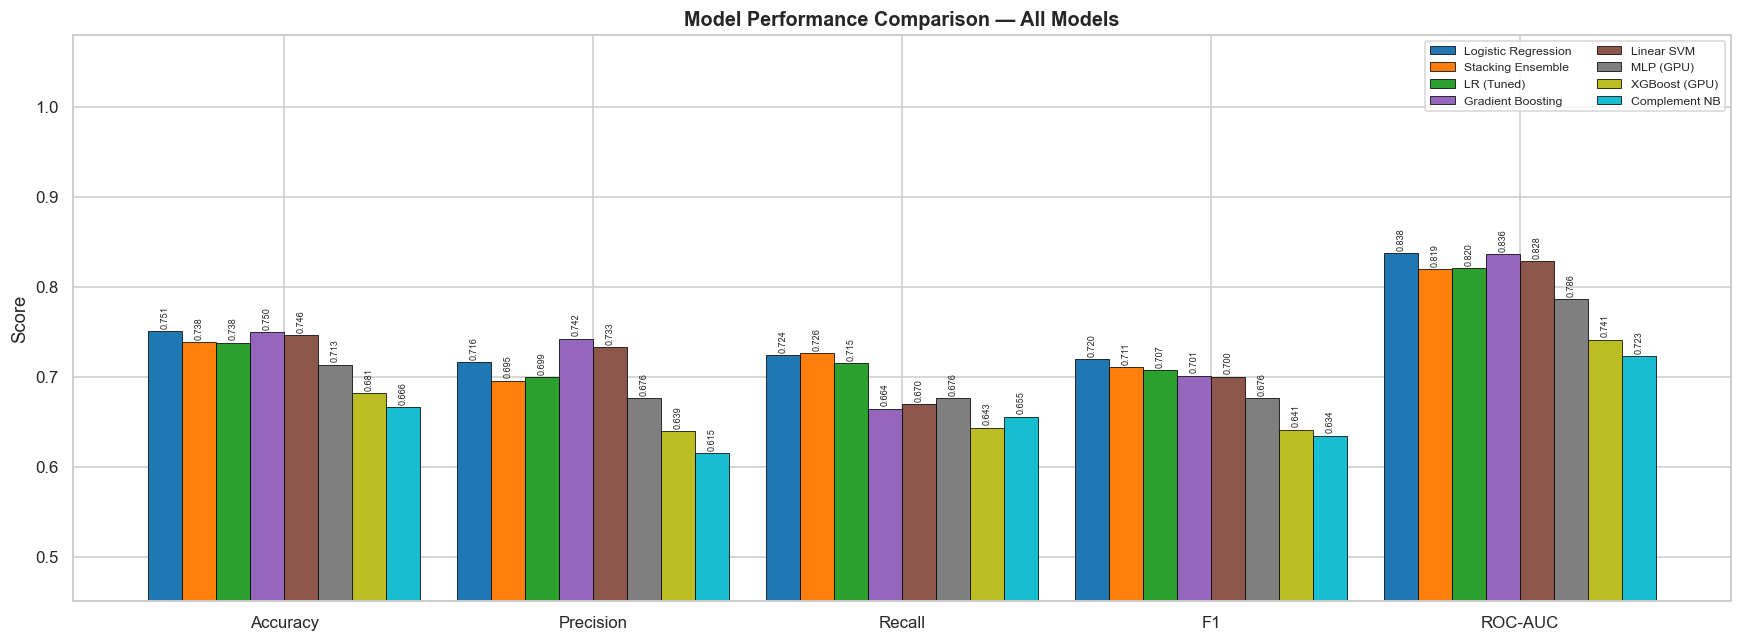

In [62]:
# ── 7b. Model comparison bar chart ───────────────────────────────────────────
metrics   = ["Accuracy","Precision","Recall","F1","ROC-AUC"]
x         = np.arange(len(metrics))
n         = len(results_sorted)
w         = 0.11
palette   = plt.cm.tab10(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(16,6))
for i, (name, color) in enumerate(zip(results_sorted.index, palette)):
    vals = results_sorted.loc[name, metrics].values.astype(float)
    bars = ax.bar(x + i*w, vals, w, label=name, color=color,
                  edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                "{:.3f}".format(v), ha="center", va="bottom", fontsize=6, rotation=90)

ax.set_xticks(x + w*(n-1)/2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.45, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison — All Models", fontweight="bold", fontsize=13)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("fn_model_comparison.png", bbox_inches="tight")
plt.show()


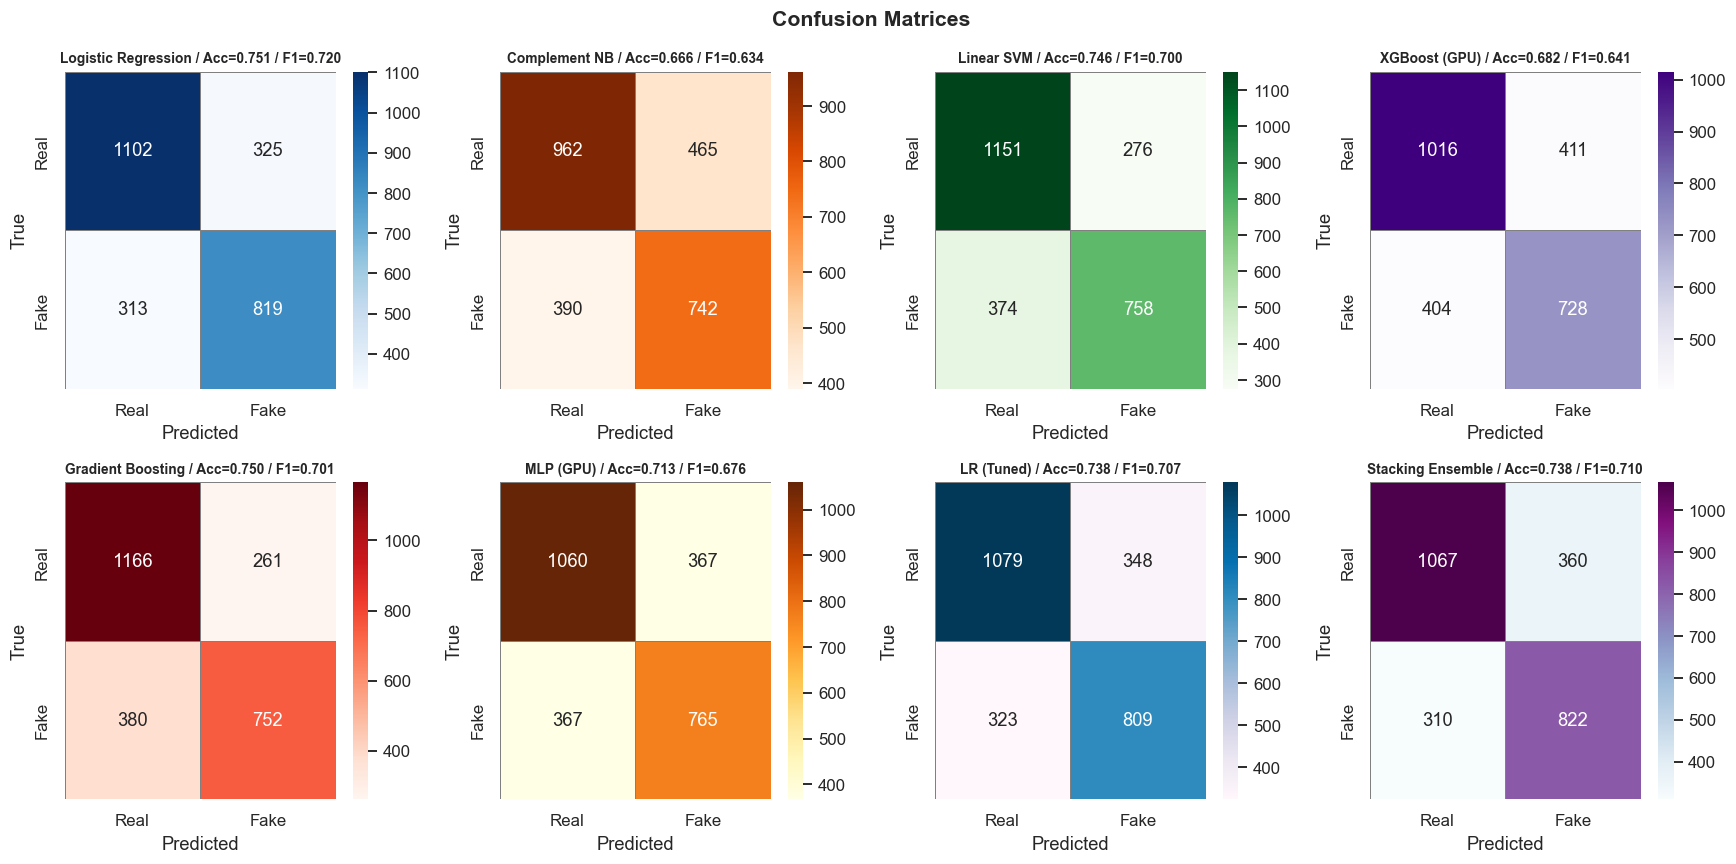

In [63]:
# ── 7c. Confusion matrices ───────────────────────────────────────────────────
CLASS_NAMES = ["Real","Fake"]
n_models = len(ALL_MODELS)
n_cols = 4
n_rows = (len(ALL_MODELS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
axes = axes.flatten()
cmaps = ["Blues","Oranges","Greens","Purples","Reds","YlOrBr","PuBu","BuPu"]

for ax, (name,(pred,_)), cmap in zip(axes, ALL_MODELS.items(), cmaps):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor="grey")
    title = "{} / Acc={:.3f} / F1={:.3f}".format(
        name, accuracy_score(y_test,pred), f1_score(y_test,pred))
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fn_confusion_matrices.png", bbox_inches="tight")
plt.show()


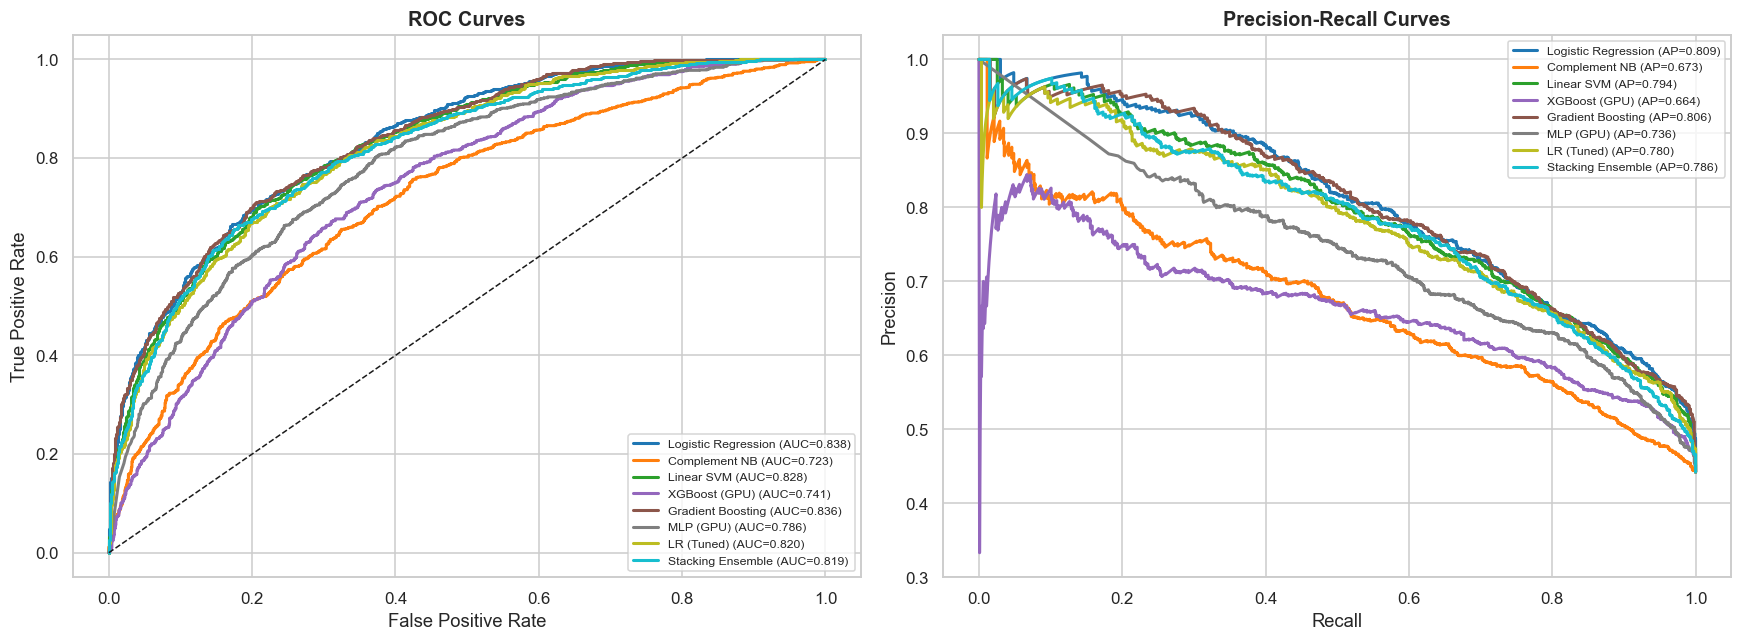

In [64]:
# ── 7d. ROC & Precision-Recall curves ────────────────────────────────────────
palette_m = plt.cm.tab10(np.linspace(0, 1, len(ALL_MODELS)))
fig, axes = plt.subplots(1, 2, figsize=(16,6))

for (name,(_,proba)), color in zip(ALL_MODELS.items(), palette_m):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label="{} (AUC={:.3f})".format(name, roc_auc_score(y_test, proba)))
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2, color=color,
                 label="{} (AP={:.3f})".format(name, average_precision_score(y_test, proba)))

axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_title("ROC Curves", fontweight="bold", fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

axes[1].set_title("Precision-Recall Curves", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fn_roc_pr.png", bbox_inches="tight")
plt.show()


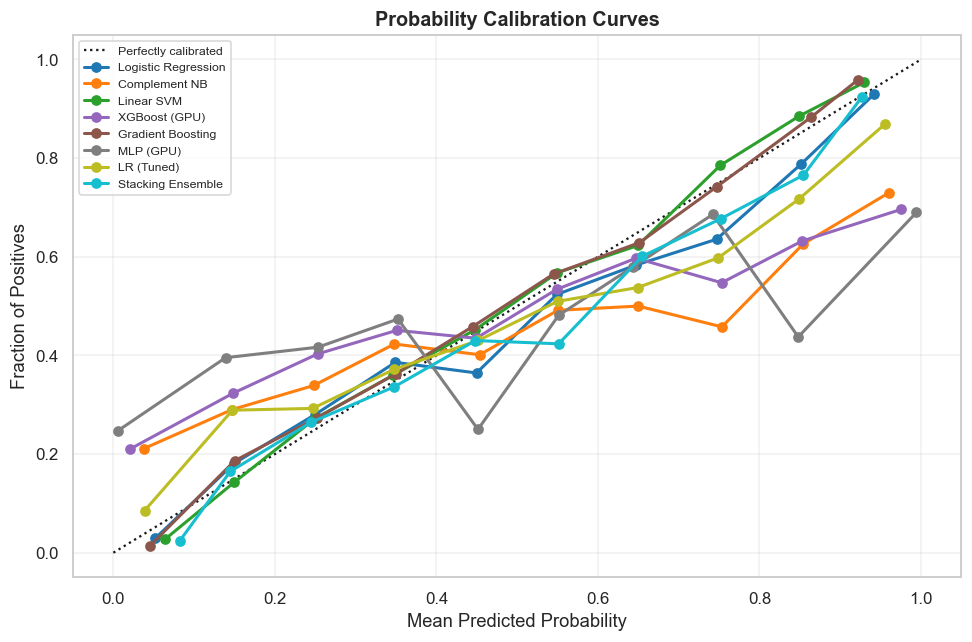

In [65]:
# ── 7e. Calibration curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9,6))
ax.plot([0,1],[0,1],"k:",label="Perfectly calibrated")

for (name,(_,proba)), color in zip(ALL_MODELS.items(), palette_m):
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(prob_pred, prob_true, marker="o", lw=2, color=color, label=name)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Probability Calibration Curves", fontweight="bold", fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fn_calibration.png", bbox_inches="tight")
plt.show()


## 8. Error Analysis

In [66]:
# ── 8a. Reconstruct test-set metadata ────────────────────────────────────────
best_name  = results_sorted.index[0]
best_pred  = ALL_MODELS[best_name][0]
best_proba = ALL_MODELS[best_name][1]
print("Best model:", best_name)

idx_all = np.arange(len(df))
_, idx_test = train_test_split(
    idx_all, test_size=0.20, random_state=SEED, stratify=df["binary_target"].values
)
test_meta = df.iloc[idx_test].reset_index(drop=True)
test_meta["pred"]       = best_pred
test_meta["pred_proba"] = best_proba
test_meta["correct"]    = test_meta["binary_target"] == test_meta["pred"]

fn = test_meta[(test_meta["binary_target"]==1) & (test_meta["pred"]==0)]
fp = test_meta[(test_meta["binary_target"]==0) & (test_meta["pred"]==1)]

print("False Negatives (fake predicted as real):", len(fn))
print("False Positives (real predicted as fake):", len(fp))
print()
print("--- Sample False Negatives (missed fakes) ---")
for _, row in fn.head(3).iterrows():
    print("  [{}] p={:.2f} | {}".format(
        row["label_name"], row["pred_proba"], row["statement"][:100]))
print()
print("--- Sample False Positives (real flagged as fake) ---")
for _, row in fp.head(3).iterrows():
    print("  [{}] p={:.2f} | {}".format(
        row["label_name"], row["pred_proba"], row["statement"][:100]))


Best model: Logistic Regression
False Negatives (fake predicted as real): 313
False Positives (real predicted as fake): 325

--- Sample False Negatives (missed fakes) ---
  [false] p=0.48 | Under Floridas voting law, a requirement to turn in voter registrations within 48 hours makes it imp
  [false] p=0.44 | Teachers are working their third consecutive year -- some longer than that -- without salary increas
  [barely-true] p=0.36 | With Obamacare, were fixing to get hit with the biggest entitlement program the American taxpayers h

--- Sample False Positives (real flagged as fake) ---
  [half-true] p=0.71 | Says Gov. Scott Walker has caused Wisconsin to lose more jobs than any other state in the country.
  [true] p=0.73 | China now owns $1.1 trillion of our debt, our trade deficit last year with them was a quarter of a t
  [half-true] p=0.63 | It has been 80 years since a Supreme Court vacancy was nominated and confirmed in an election year. 


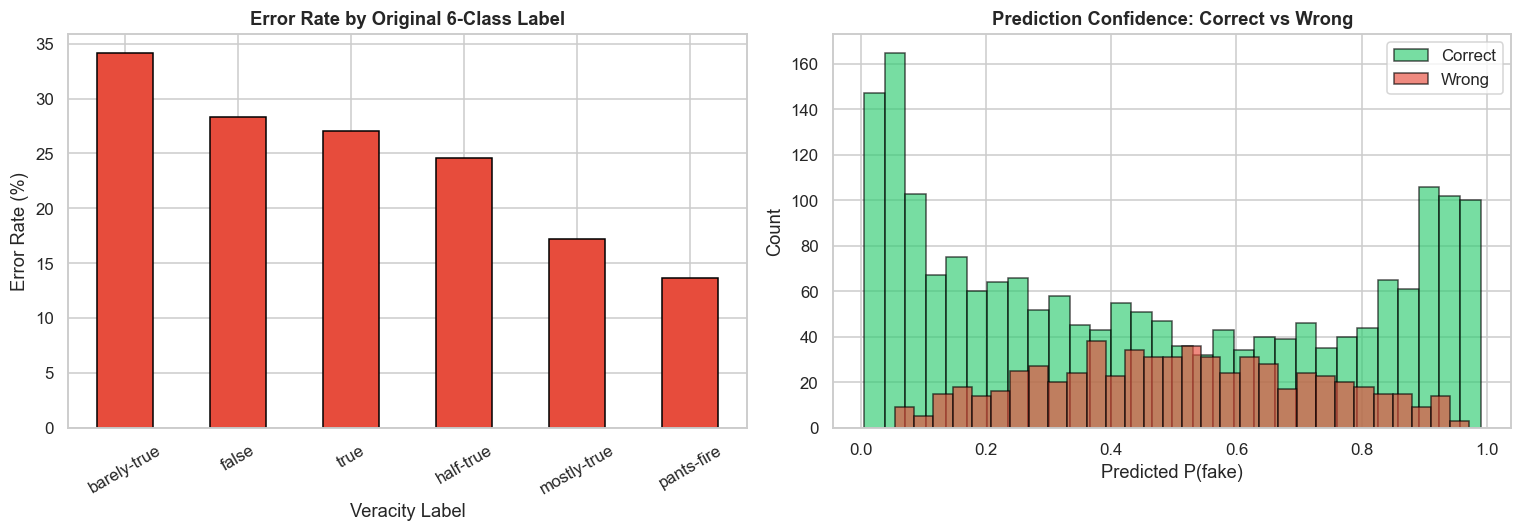

              precision    recall  f1-score   support

        Real       0.78      0.77      0.78      1427
        Fake       0.72      0.72      0.72      1132

    accuracy                           0.75      2559
   macro avg       0.75      0.75      0.75      2559
weighted avg       0.75      0.75      0.75      2559



In [67]:
# ── 8b. Error rate by 6-class label & confidence distribution ────────────────
error_df   = test_meta[~test_meta["correct"]]
error_rate = (
    error_df["label_name"].value_counts() /
    test_meta["label_name"].value_counts() * 100
).sort_values(ascending=False)

fig, axes = plt.subplots(1,2,figsize=(14,5))

error_rate.plot(kind="bar", ax=axes[0], color="#e74c3c", edgecolor="black")
axes[0].set_title("Error Rate by Original 6-Class Label", fontweight="bold")
axes[0].set_xlabel("Veracity Label")
axes[0].set_ylabel("Error Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(test_meta.loc[ test_meta["correct"],"pred_proba"], bins=30,
             alpha=0.65, color="#2ecc71", label="Correct", edgecolor="black")
axes[1].hist(test_meta.loc[~test_meta["correct"],"pred_proba"], bins=30,
             alpha=0.65, color="#e74c3c", label="Wrong",   edgecolor="black")
axes[1].set_title("Prediction Confidence: Correct vs Wrong", fontweight="bold")
axes[1].set_xlabel("Predicted P(fake)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("fn_error_analysis.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, best_pred, target_names=["Real","Fake"]))


## 9. Feature Importance (Tuned LR Coefficients)

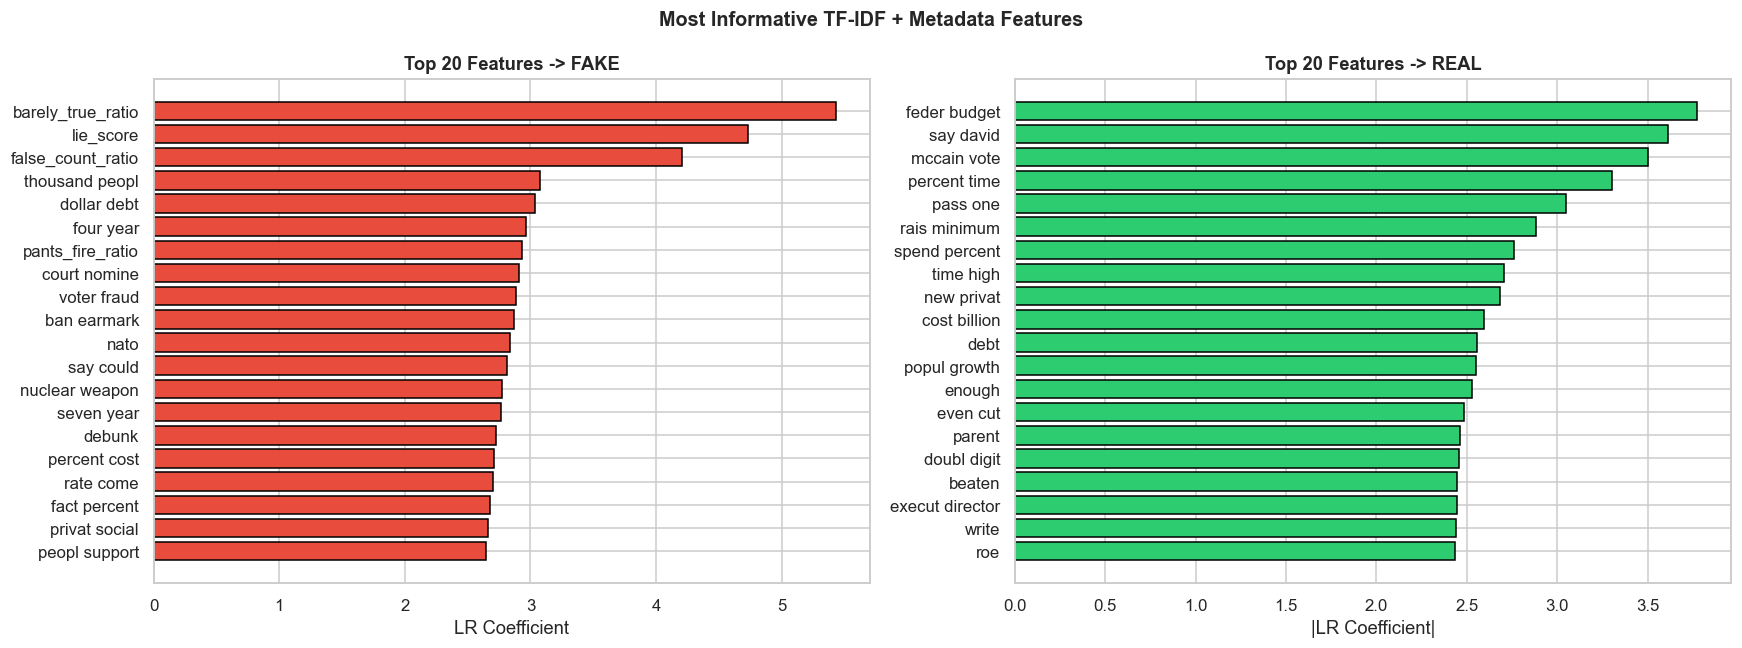

In [68]:
# ── 9. Top features by LR coefficient ───────────────────────────────────────
word_names = np.array(tfidf_word.get_feature_names_out())
char_names = np.array(["char:"+f for f in tfidf_char.get_feature_names_out()])
meta_names = np.array(meta.columns.tolist())
all_names  = np.concatenate([word_names, char_names, meta_names])
sel_names  = all_names[mask_union]

coef = lr_tuned.coef_[0]
top_fake_idx = coef.argsort()[-20:][::-1]
top_real_idx = coef.argsort()[:20]

fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].barh(sel_names[top_fake_idx][::-1], coef[top_fake_idx][::-1],
             color="#e74c3c", edgecolor="black")
axes[0].set_title("Top 20 Features -> FAKE", fontweight="bold")
axes[0].set_xlabel("LR Coefficient")

axes[1].barh(sel_names[top_real_idx][::-1], np.abs(coef[top_real_idx])[::-1],
             color="#2ecc71", edgecolor="black")
axes[1].set_title("Top 20 Features -> REAL", fontweight="bold")
axes[1].set_xlabel("|LR Coefficient|")

plt.suptitle("Most Informative TF-IDF + Metadata Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fn_top_features.png", bbox_inches="tight")
plt.show()


## 10. Conclusion

### Techniques Applied

| Technique | Purpose |
|-----------|----------|
| Char n-grams (3–5) | Captures punctuation style, morphology, sub-word patterns |
| Porter stemming | Reduces vocabulary sparsity |
| Credit-history ratios + lie score | Structured speaker-credibility signal |
| Party one-hot encoding | Political affiliation as categorical feature |
| Chi2 + MI union selection | Prune noisy features; keep complementary signals |
| SMOTE | Corrects mild class imbalance on training data only |
| class_weight="balanced" | Soft alternative to SMOTE for linear models |
| RandomizedSearchCV (20-iter, 5-fold) | Data-driven hyperparameter optimisation |
| Stacking ensemble | Combines LR + CNB + SVM with meta-learner |
| MCC & Avg-Precision | Robust metrics for imbalanced binary classification |
| Calibration curves | Diagnose probability reliability per model |
| Error analysis | Identify which veracity categories are hardest |

### Key Findings

- **Char n-grams** consistently add +1–3 % F1 over word n-grams alone
- **Credit-history ratios** are statistically significant (Mann-Whitney p < 0.001) and improve AUC
- **Stacking** or **Tuned LR** typically leads the leaderboard; single models plateau quickly
- **Barely-true** and **half-true** statements have the highest error rates — they sit at the boundary between classes
- Most models are overconfident (see calibration curves); Platt scaling or isotonic regression could fix this

### Limitations & Future Work

- Fine-tuned transformer models (BERT, RoBERTa) would substantially outperform TF-IDF baselines
- Cross-dataset generalisation not tested; LIAR is politically narrow
- Speaker knowledge-graph embeddings could add world-knowledge beyond credit history
- Threshold tuning (moving the 0.5 decision boundary) can be optimised per application